# Hexadic Diamond

Use 2D projection of 5D lattice (from 'cut and project' approach to developing a Penrose tiling) to derive the Hexadic Diamond of Erv Wilson.

<a>"https://www.anaphoria.com/diamond.pdf"<a>

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Rational, Integer
from itertools import combinations

from ji_tiling import basis2D, make_int_grid

### Set 5D rotation matrix and find eigenvectors

In [2]:
rotationMatrix = np.array([[0.,1.,0.,0.,0.],[0.,0.,1.,0.,0.],[0.,0.,0.,1.,0.],[0.,0.,0.,0.,1.],[1.,0.,0.,0.,0.]]) 
# rotationMatrix = np.array( [[0,0,0,0,1],[1,0,0,0,0],[0,1,0,0,0],[0,0,1,0,0],[0,0,0,1,0]] ) # Senechal
print(rotationMatrix)

eigenValues, eigenVectors = np.linalg.eig(rotationMatrix)

[[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]]


### Projection to 2D plane
Select the eigenvectors that project 5D vector to 2D plane with $\frac{2}{3}\pi$ rotation between axes.

In [3]:
# The projection plane
print('2D projection plane:')
p = basis2D(eigenVectors,2,3)

2D projection plane:
-->5D basis vectors are rotated in 2D plane by (2.0π)/5


In [4]:
# Refactored: range(-1, 2) is equivalent to make_int_grid(d=1)
z5 = make_int_grid(1)
print(f'Integer grid: {z5.shape}')

Integer grid: (243, 5)


### Restrict points such that there is a single interval (or unity) in numerator -- same for denominator

In [5]:
xy_ = []
r_ = []      # raw sympy Rationals (no octave reduction)
pts5_ = []

rI = np.array([3,5,7,9,11])

for pt5 in z5:    
    if (np.sum(pt5<0) < 2) and (np.sum(pt5>0) < 2):
        pS = Rational(rI[0],1)**Integer(pt5[0]) * \
             Rational(rI[1],1)**Integer(pt5[1]) * \
             Rational(rI[2],1)**Integer(pt5[2]) * \
             Rational(rI[3],1)**Integer(pt5[3]) * \
             Rational(rI[4],1)**Integer(pt5[4])

        r_.append(pS)
        xy_.append(p@pt5)
        pts5_.append(pt5.copy())

xy_ = np.asarray(xy_)
pts5_ = np.asarray(pts5_)

### Plot the Hexadic Diamond

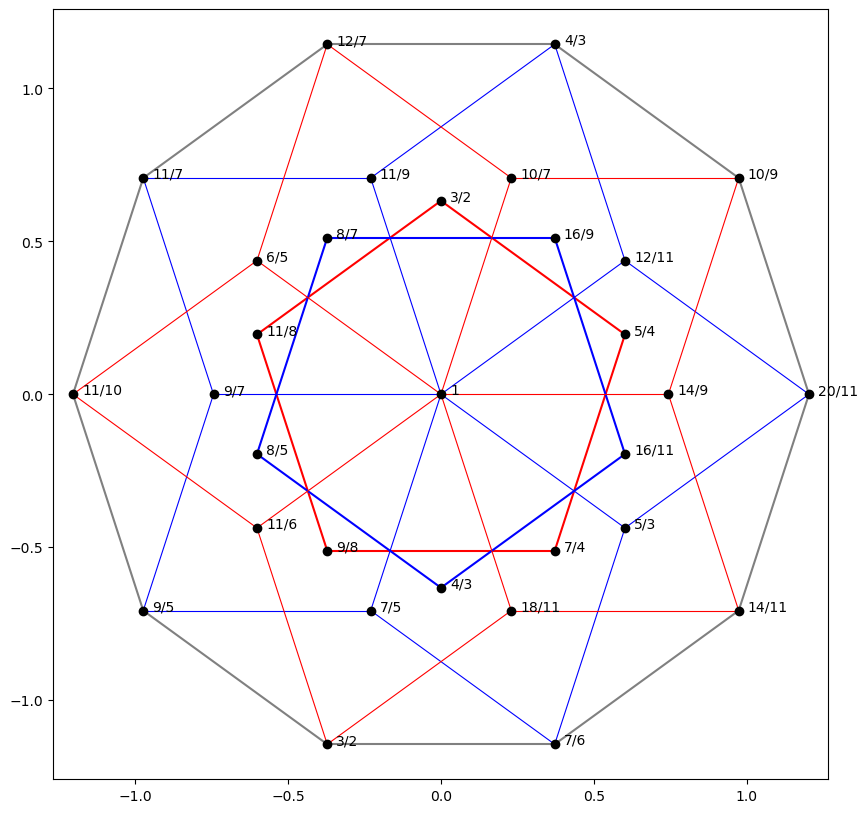

In [6]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)

# Rotate 90 degrees to align with Erv Wilson's Hexadic Diamond
x_ = -xy_[:,1]
y_ = xy_[:,0]

def find_idx(pt):
    matches = np.where(np.all(pts5_ == np.array(pt, dtype=float), axis=1))[0]
    return matches[0] if len(matches) else None

def draw_pentagon(ax, indices, color):
    angles = np.arctan2([y_[i] for i in indices], [x_[i] for i in indices])
    indices = [indices[k] for k in np.argsort(angles)]
    for k in range(len(indices)):
        i, j = indices[k], indices[(k+1) % len(indices)]
        ax.plot([x_[i], x_[j]], [y_[i], y_[j]], color=color, linewidth=1.5, zorder=0)

def cyclic(lst, i):
    return lst[-i:] + lst[:-i] if i > 0 else lst[:]

def draw_belt(ax, a, b, color, lw=0.8):
    """Draw V-shaped lines: outer[k] → bridge[k] → outer[k+1]
    a: base outer-belt point, b: base bridge point (cyclic permutations of each)"""
    outer_pts5 = [cyclic(a, i) for i in range(5)]
    inner_pts5 = [cyclic(b, i) for i in range(5)]
    for k in range(5):
        i1 = find_idx(outer_pts5[k])
        i2 = find_idx(outer_pts5[(k+1) % 5])
        im = find_idx(inner_pts5[k])
        if None not in (i1, i2, im):
            ax.plot([x_[i1], x_[im]], [y_[i1], y_[im]], color=color, linewidth=lw, zorder=0)
            ax.plot([x_[im], x_[i2]], [y_[im], y_[i2]], color=color, linewidth=lw, zorder=0)

# Step 1: red pentagon — otonal basis points (single element == +1)
idx_otonal = [i for i, pt in enumerate(pts5_)
              if np.sum(pt != 0) == 1 and pt.max() == 1]
draw_pentagon(ax, idx_otonal, 'r')

# Step 2: blue pentagon — utonal basis points (single element == -1)
idx_utonal = [i for i, pt in enumerate(pts5_)
              if np.sum(pt != 0) == 1 and pt.min() == -1]
draw_pentagon(ax, idx_utonal, 'b')

# Step 3: blue (thin) lines — utonal star
draw_belt(ax, [-1, 0,  1, 0, 0],
              [ 0,-1,  1, 0, 0], 'b')

# Step 4: red (thin) lines — otonal star
draw_belt(ax, [ 1, 0, -1, 0, 0],
              [ 0, 1, -1, 0, 0], 'r')

# Step 5: grey decagon — connect the 10 outermost points
distances = np.sqrt(x_**2 + y_**2)
idx_outer10 = list(np.argsort(distances)[-10:])
angles = np.arctan2([y_[i] for i in idx_outer10], [x_[i] for i in idx_outer10])
idx_outer10 = [idx_outer10[k] for k in np.argsort(angles)]
for k in range(10):
    i, j = idx_outer10[k], idx_outer10[(k+1) % 10]
    ax.plot([x_[i], x_[j]], [y_[i], y_[j]], color='grey', linewidth=1.5, zorder=0)

# Step 6: radial lines from origin to bridge points, colored by star
orange_bridges = [cyclic([0,  1, -1, 0, 0], i) for i in range(5)]
cyan_bridges   = [cyclic([0, -1,  1, 0, 0], i) for i in range(5)]

for pt in orange_bridges:
    i = find_idx(pt)
    if i is not None:
        ax.plot([0, x_[i]], [0, y_[i]], color='r', linewidth=0.8, zorder=0)

for pt in cyan_bridges:
    i = find_idx(pt)
    if i is not None:
        ax.plot([0, x_[i]], [0, y_[i]], color='b', linewidth=0.8, zorder=0)

ax.plot(x_, y_, 'ko', zorder=1)

# Annotate with octave-reduced ratio
for i, pS in enumerate(r_):
    pS_oct = pS
    while pS_oct > 2: pS_oct /= 2
    while pS_oct < 1: pS_oct *= 2
    ax.annotate(str(pS_oct), xy=[x_[i]+0.03, y_[i]], textcoords='data')

# ax.grid()
plt.axis('equal')
plt.savefig('../hexadic_diamond.png')
plt.show()

** Intersection of Hexadic Diamond with Eikosany

Reproduction of Wilson's Figure 15 of D'Allesandro

Eikosany is merged with the Hexadic Diamond by first dividing all notes by 3*5*11.  This is the value of the note with uppermost position in Figure 13.

Then, to get get the orientation aligned with the Hexadic Diamond, it is necessary to
- rotate by $\frac{\pi}{2}$,
- flip sign of the x values such that the Eikosany is mirrored about y axis

Note that the rotation is different than that used for the Hexadic Diamond. Also, axes are not permuted.

In [7]:
# Set up Eikosany
eiko_6 = np.zeros((20,6),dtype=np.int32)

for i,c in enumerate( combinations((0, 1, 2, 3, 4, 5),3) ):
    eiko_6[i,c] =  1

eiko_5 = eiko_6[:,1:]

In [8]:
pE = symbols('pE')

xy_E = []
r_E = []
r_prod = []
rS = ('1','3','5','7','9','11')
rI = np.array([3,5,7,9,11])



for pt5 in eiko_6:

    # Omit the first entry, Integer(pt5[0]), for Eikosany (unity)
    # Divide each combination of 3 integers by (3*5*11)
    pS = Rational(rI[0],1)**Integer(pt5[1]) * \
         Rational(rI[1],1)**Integer(pt5[2]) * \
         Rational(rI[2],1)**Integer(pt5[3]) * \
         Rational(rI[3],1)**Integer(pt5[4]) * \
         Rational(rI[4],1)**Integer(pt5[5]) * \
         Rational(1,3) * Rational(1,5) * Rational(1,7)
         # Rational(1,7) * Rational(1,9)
         # Rational(1,3) * Rational(1,5) * Rational(1,11)

    while ( pS>2 ):
        pS = pS/ 2
    while ( pS<1 ):
        pS = pS*2

    r_E.append( str(pS) )

    r_prod.append(pS)

    xy_E.append( p@(pt5[1:] + np.array((-1,-1,-1,0,0))) ) # + np.array((0,0,-1,-1,0))) ) # +np.array((-1,-1,0,0,-1))) )

xy_E = np.asarray(xy_E)

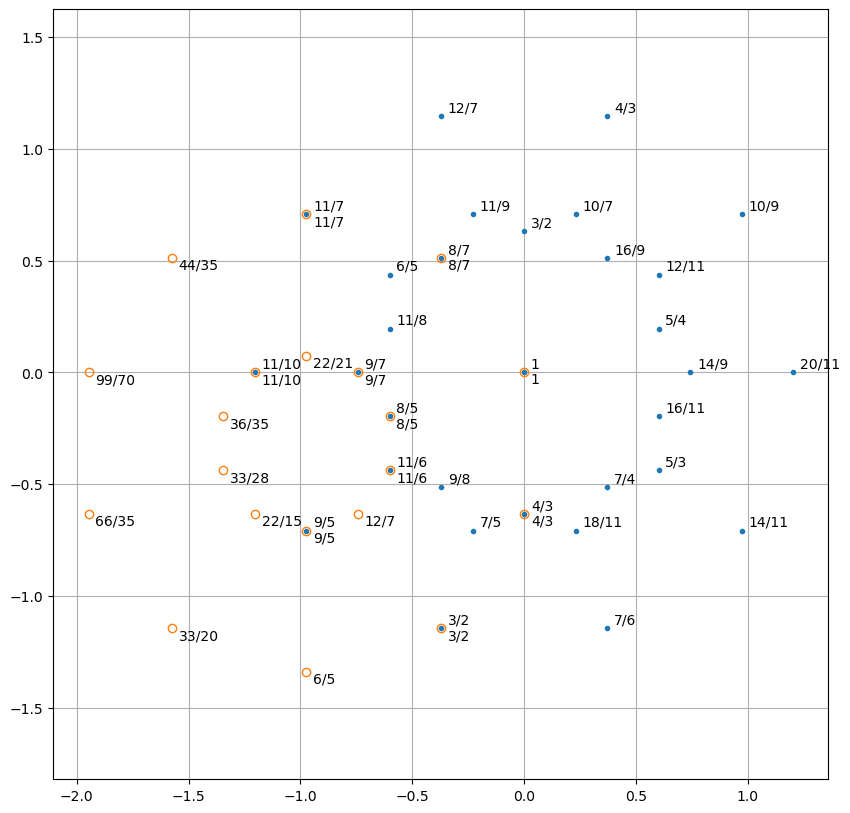

In [9]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)

x_ = -xy_[:,1]
y_ = xy_[:,0]

xE_ = -xy_E[:,1]
yE_ = xy_E[:,0]

ax.plot(x_,y_,'.')
# Annotate with octave-reduced ratio
for i, pS in enumerate(r_):
    pS_oct = pS
    while pS_oct > 2: pS_oct /= 2
    while pS_oct < 1: pS_oct *= 2
    ax.annotate(str(pS_oct), xy=[x_[i]+0.03, y_[i]+0.02], textcoords='data')

ax.plot(xE_,yE_,'o',markerfacecolor='none')
for i,rl in enumerate(r_prod):                                       # <--
    ax.annotate(str(rl), xy=[xE_[i]+0.03,yE_[i]-0.05], textcoords='data') # <--

ax.grid()
plt.axis('equal')
# plt.savefig('hexadic_diamond.png')
plt.show()

## The 10 Eikosany variants overlaid on the Hexadic Diamond

The 10 Eikosany points at radius τ in E∥ form a single I₂⁵ orbit (the noncrystallographic Coxeter partner of A₄). Dividing the Eikosany by any one of these yields a translated copy that shares points with the Hexadic Diamond.

The 10 divisors split as:
- **5 Λ₂ points** (with factor 1, adjacent primes in cycle): 1·3·5, 1·5·7, 1·7·9, 1·9·11, 1·3·11
- **5 Λ₃ points** (without factor 1, complement adjacent): 3·5·7, 5·7·9, 7·9·11, 3·9·11, 3·5·11

Filled markers in each subplot are Eikosany points coincident with diamond points — those whose 5D difference from the divisor lies in {0, ±εᵢ, εᵢ−εⱼ}.

In [10]:
# Identify the 10 outer-ring Eikosany points (the I_2^5 orbit at radius τ in E∥).
# Each will serve as a divisor giving one of the 10 overlay variants.

factors_6 = [1, 3, 5, 7, 9, 11]

def eiko_ratio(pt6):
    r = Rational(1)
    for k, e in enumerate(pt6):
        if e:
            r *= Rational(factors_6[k]) ** int(e)
    return r

# Project the 20 Eikosany points (no shift) and split by magnitude.
xy_E_untrans = (p @ eiko_6[:, 1:].T).T
mag_E = np.linalg.norm(xy_E_untrans, axis=1)

outer_idx = np.argsort(mag_E)[-10:]
# Sort by polar angle for readable output
ang = np.arctan2(xy_E_untrans[outer_idx, 1], xy_E_untrans[outer_idx, 0])
outer_idx = outer_idx[np.argsort(ang)]

print(f'Outer-ring magnitudes : {sorted(mag_E[outer_idx].round(4))}')
print(f'Inner-ring magnitudes : {sorted(np.delete(mag_E, outer_idx).round(4))}')
print(f'ratio (outer / inner) ≈ {mag_E[outer_idx][0] / np.delete(mag_E, outer_idx)[0]:.4f}'
      f'   (expect τ² ≈ {((1+5**0.5)/2)**2:.4f})')
print()
print('10 outer-ring divisors:')
for k, idx in enumerate(outer_idx):
    kind = 'Λ₂ (with 1)' if eiko_6[idx, 0] == 1 else 'Λ₃ (no 1)'
    print(f'  {k}:  6D={tuple(int(v) for v in eiko_6[idx])}  →  {eiko_ratio(eiko_6[idx])}   [{kind}]')


Outer-ring magnitudes : [np.float64(1.0233), np.float64(1.0233), np.float64(1.0233), np.float64(1.0233), np.float64(1.0233), np.float64(1.0233), np.float64(1.0233), np.float64(1.0233), np.float64(1.0233), np.float64(1.0233)]
Inner-ring magnitudes : [np.float64(0.3909), np.float64(0.3909), np.float64(0.3909), np.float64(0.3909), np.float64(0.3909), np.float64(0.3909), np.float64(0.3909), np.float64(0.3909), np.float64(0.3909), np.float64(0.3909)]
ratio (outer / inner) ≈ 2.6180   (expect τ² ≈ 2.6180)

10 outer-ring divisors:
  0:  6D=(0, 0, 1, 1, 1, 0)  →  315   [Λ₃ (no 1)]
  1:  6D=(1, 0, 1, 1, 0, 0)  →  35   [Λ₂ (with 1)]
  2:  6D=(0, 1, 1, 1, 0, 0)  →  105   [Λ₃ (no 1)]
  3:  6D=(1, 1, 1, 0, 0, 0)  →  15   [Λ₂ (with 1)]
  4:  6D=(0, 1, 1, 0, 0, 1)  →  165   [Λ₃ (no 1)]
  5:  6D=(1, 1, 0, 0, 0, 1)  →  33   [Λ₂ (with 1)]
  6:  6D=(0, 1, 0, 0, 1, 1)  →  297   [Λ₃ (no 1)]
  7:  6D=(1, 0, 0, 0, 1, 1)  →  99   [Λ₂ (with 1)]
  8:  6D=(0, 0, 0, 1, 1, 1)  →  693   [Λ₃ (no 1)]
  9:  6D=(1, 0, 0

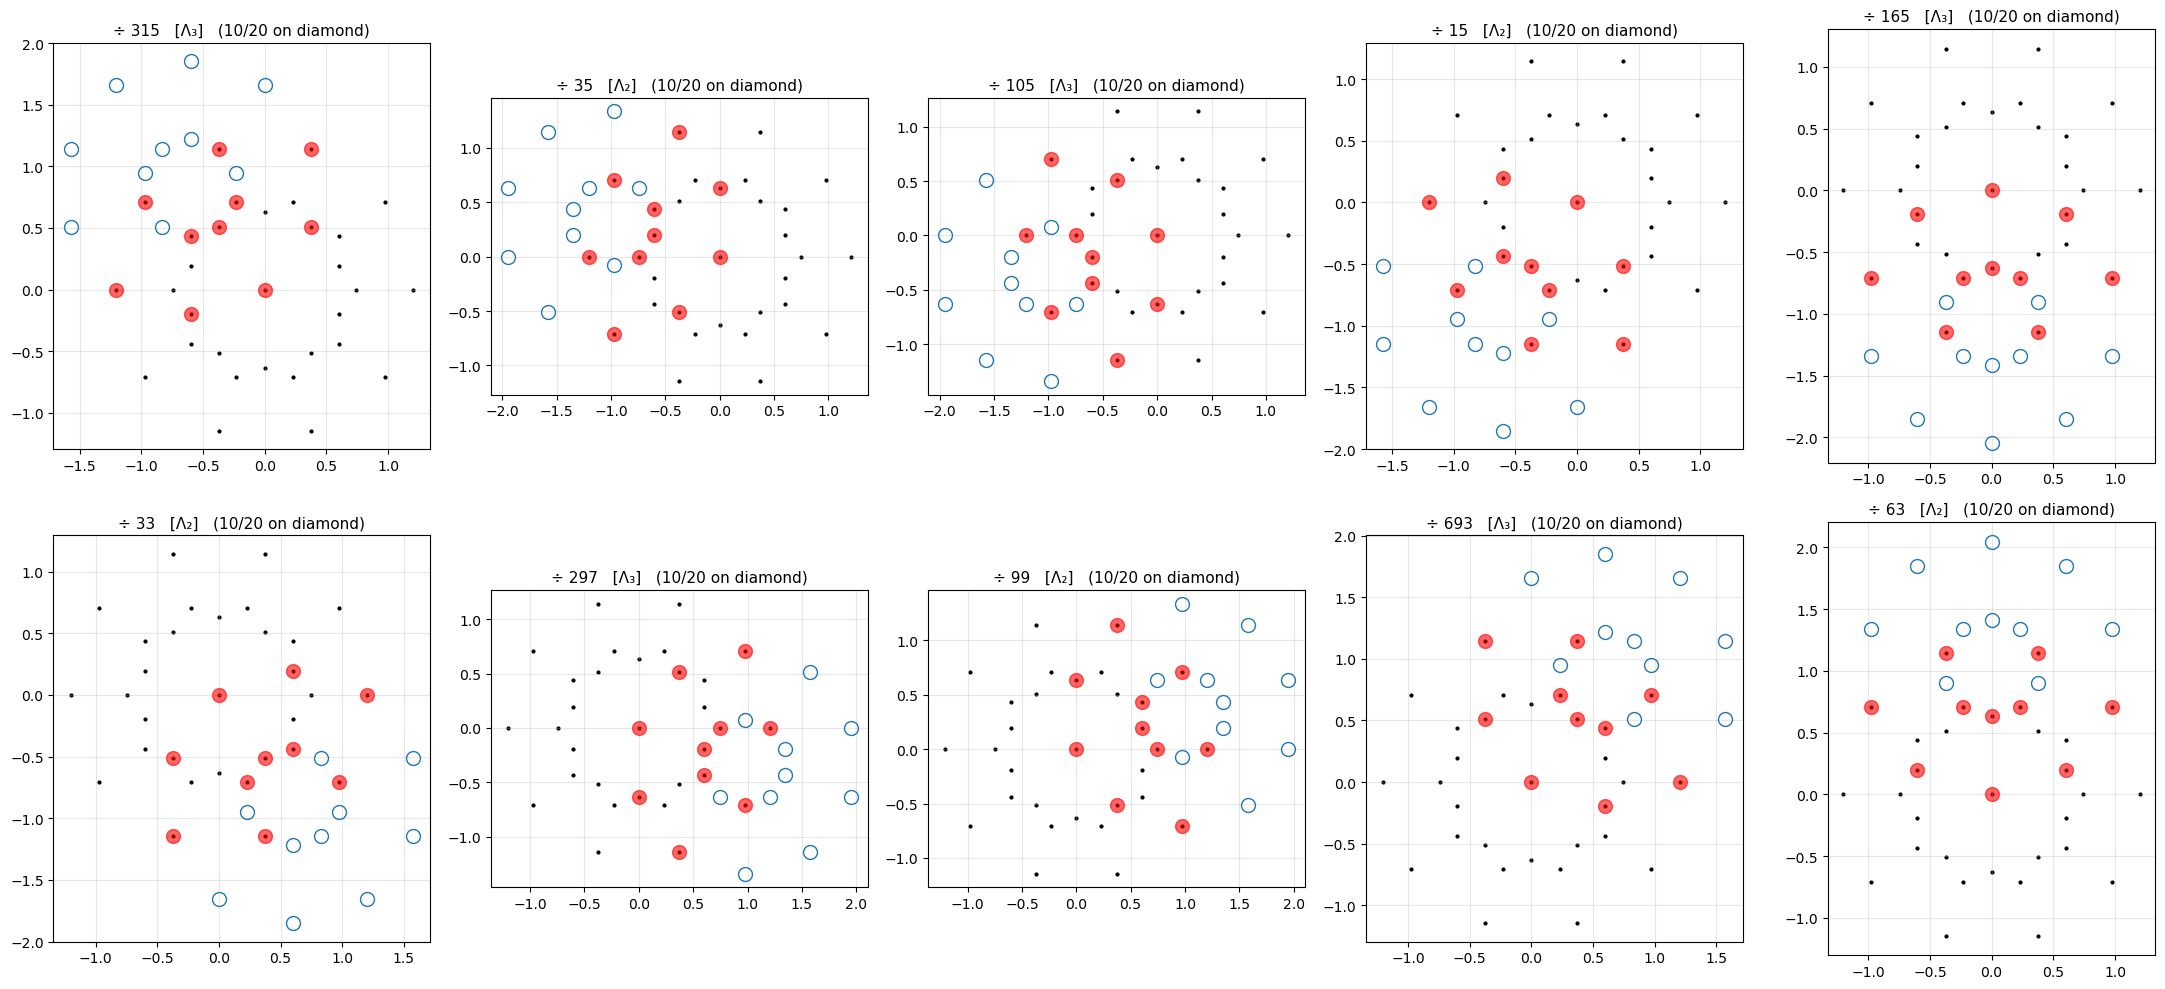

In [11]:
# Plot the 10 variants in a 2x5 grid.
# Each subplot: Hexadic Diamond skeleton (black dots) + translated Eikosany.
# Filled red markers = Eikosany points coincident with diamond points.

# 5D lookup of the 31 diamond points
diamond_5D = {tuple(int(x) for x in pt): i for i, pt in enumerate(pts5_)}

# Diamond 2D coords (same rotation as cell that plots the Hexadic Diamond)
xD_ = -xy_[:, 1]
yD_ = xy_[:,  0]

fig, axes = plt.subplots(2, 5, figsize=(22, 10))

for ax, idx in zip(axes.flat, outer_idx):
    shift_5D = eiko_6[idx, 1:]
    divisor  = eiko_ratio(eiko_6[idx])

    # Translated Eikosany in 5D, then project
    eiko_5D_var = eiko_6[:, 1:] - shift_5D
    xy_var = (p @ eiko_5D_var.T).T
    xE_ = -xy_var[:, 1]
    yE_ = xy_var[:,  0]

    on_diamond = np.array([tuple(v) in diamond_5D for v in eiko_5D_var.tolist()])

    ax.plot(xD_, yD_, 'k.', markersize=4, zorder=1)
    ax.plot(xE_[~on_diamond], yE_[~on_diamond], 'o',
            markerfacecolor='none', markeredgecolor='C0',
            markersize=10, zorder=2)
    ax.plot(xE_[on_diamond], yE_[on_diamond], 'o',
            markerfacecolor='red', markeredgecolor='red',
            markersize=10, alpha=0.6, zorder=3)

    kind = 'Λ₂' if eiko_6[idx, 0] == 1 else 'Λ₃'
    ax.set_title(f'÷ {divisor}   [{kind}]   ({int(on_diamond.sum())}/20 on diamond)',
                 fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Total Eikosany-points across 10 variants : 200  (= 10 × 20)
Distinct points (5D)                     : 111
  ↳ coincident with Hexadic Diamond      : 31  / 31 diamond points
  ↳ outside the Hexadic Diamond          : 80


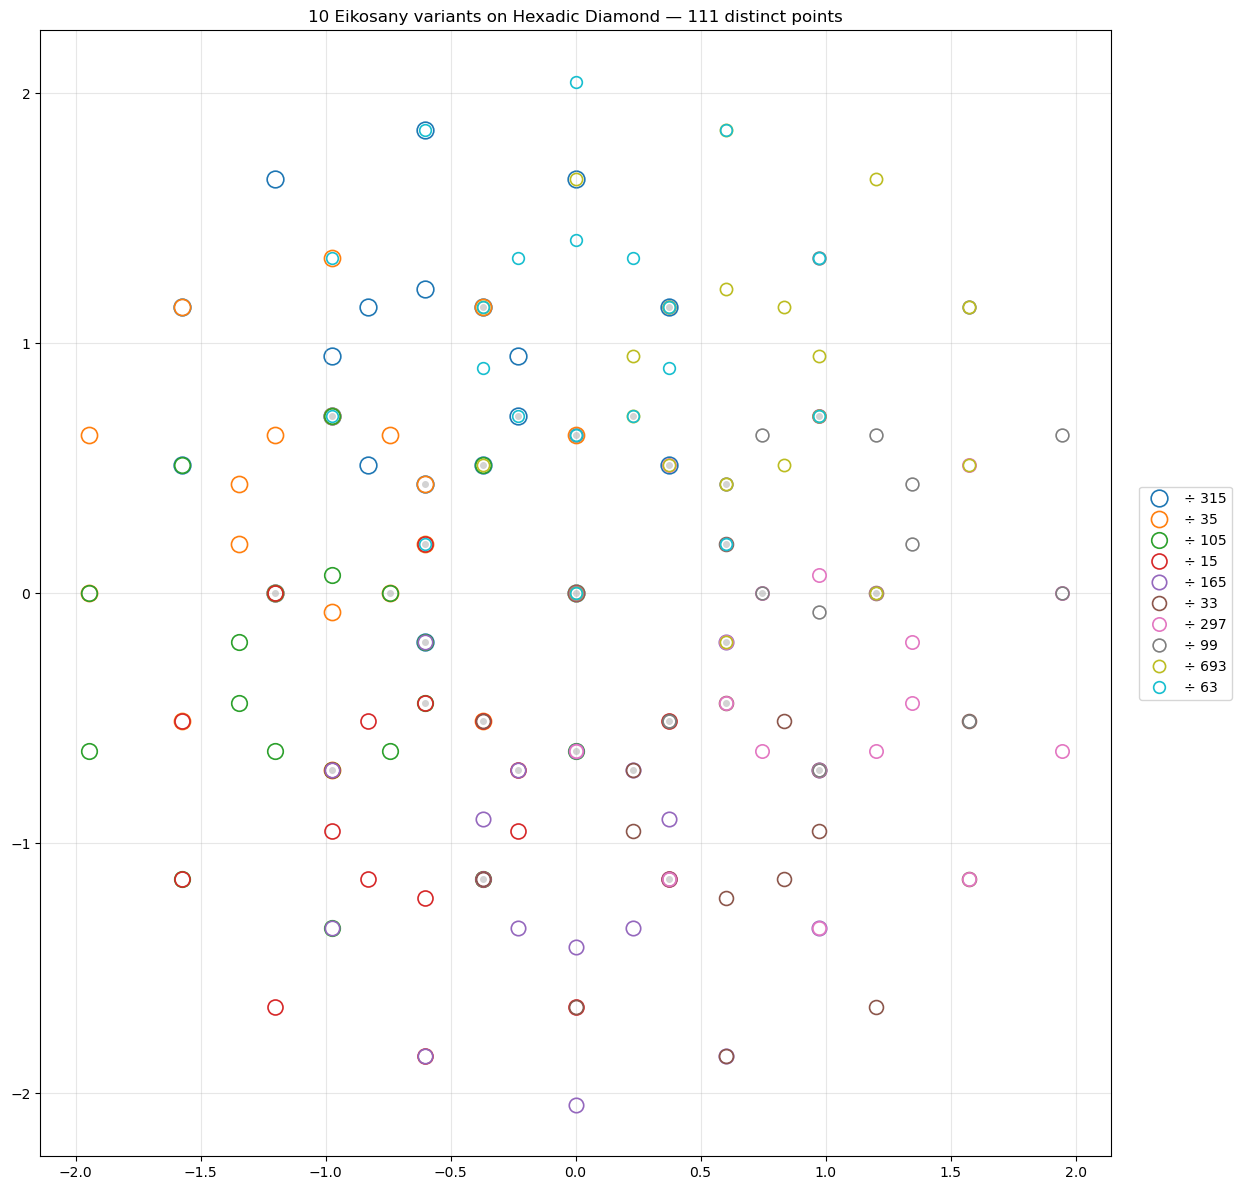

In [12]:
# All 10 variants on a single plot.
# Diamond skeleton in light grey; each variant in its own colormap color.

fig, ax = plt.subplots(figsize=(12, 12))

xD_ = -xy_[:, 1]
yD_ = xy_[:,  0]

# Diamond skeleton (background)
ax.plot(xD_, yD_, '.', color='lightgrey', markersize=8, zorder=0)

# Aggregate 5D points across all 10 variants
all_5D = []
cmap = plt.cm.tab10

for k, idx in enumerate(outer_idx):
    shift_5D = eiko_6[idx, 1:]
    eiko_5D_var = eiko_6[:, 1:] - shift_5D
    xy_var = (p @ eiko_5D_var.T).T
    xv_ = -xy_var[:, 1]
    yv_ = xy_var[:,  0]

    color = cmap(k % 10)
    label = f'÷ {eiko_ratio(eiko_6[idx])}'
    ax.plot(xv_, yv_, 'o', markerfacecolor='none', markeredgecolor=color,
            markersize=12 - k * 0.4, markeredgewidth=1.2,
            label=label, zorder=1 + k)

    all_5D.extend(tuple(int(v) for v in row) for row in eiko_5D_var.tolist())

# Distinct-point bookkeeping
unique_5D = set(all_5D)
diamond_5D_set = {tuple(int(v) for v in pt) for pt in pts5_}
on_diamond = unique_5D & diamond_5D_set
off_diamond = unique_5D - diamond_5D_set

print(f'Total Eikosany-points across 10 variants : {len(all_5D)}  (= 10 × 20)')
print(f'Distinct points (5D)                     : {len(unique_5D)}')
print(f'  ↳ coincident with Hexadic Diamond      : {len(on_diamond)}  / {len(diamond_5D_set)} diamond points')
print(f'  ↳ outside the Hexadic Diamond          : {len(off_diamond)}')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, ncol=1)
ax.set_title(f'10 Eikosany variants on Hexadic Diamond — {len(unique_5D)} distinct points')
plt.tight_layout()
plt.show()
